# Codon Optimization with THRML

The first three examples used THRML to **sample** from probability distributions. This one is about **optimization**: using the very same sampling machinery to *find a good solution* to a real-world design problem.

The problem we tackle, **codon optimization**, comes from biology and drug development, and it is a nice showcase because it touches several THRML features at once: categorical (Potts) variables, simulated annealing, and a re-encoding of a categorical model into a binary (Ising) one — the form that Extropic's hardware runs natively.

This example is based on Extropic's codon-optimization paper *(reference to be added)*. The full code for that paper — including the extra energy term we drop here for simplicity — is available at [github.com/extropic-ai/codon_opt](https://github.com/extropic-ai/codon_opt).

> We assume you have read the earlier examples, especially **example 00** (Potts models, `CategoricalEBMFactor`, block Gibbs sampling) and **example 02** (spin/Ising models). We will lean on those rather than re-explaining the basics.

## The pipeline at a glance

Before diving in, here is the whole journey this notebook takes — the same three stages laid out in the paper this example is based on:

<center>
<img src="../codon_pipeline.png" style="width:100%; max-width:1000px; background:white; padding:12px; border-radius:8px;">
</center>

*__From codons to Ising spins.__
**(a)** The codon optimization problem: each amino acid in the protein is spelled by one of several *synonymous* codons, and we choose codons that optimize usage frequency and repeat avoidance (the full paper additionally targets GC content, which we drop here).
**(b)** The **Potts model**: each amino-acid position becomes a categorical variable on a chain graph, which is 2-colorable, enabling parallel block Gibbs updates. Each $K$-state variable is then re-encoded as $K{-}1$ binary spins in a thermometer pattern (*domain-wall encoding*), where the position of the domain wall encodes the categorical state.
**(c)** The resulting **Ising model**: within-position *constraint* edges enforce valid thermometers and between-position *interaction* edges carry the codon couplings. The graph is 4-colorable for parallel updates; the full spike protein maps to 3,147 spins.*

> **Scale note.** The figure quotes numbers for the *full* 1,273-amino-acid spike protein (3,147 spins). To keep this notebook fast we actually optimize only its first 100 amino acids (266 spins), but the code is identical and scales to the full protein unchanged.

We build each of these pieces in turn below: the Potts model first (panels **a–b**), then its domain-wall Ising encoding (panels **b–c**).

## Optimization with energy-based models

Recall that an energy-based model (EBM) assigns a probability to every configuration $x$ through an *energy function* $E(x)$:

$$ \mathbb{P}(X = x) \propto e^{-\beta E(x)}. $$

Low-energy configurations are the most probable. The parameter $\beta$ (inverse temperature) controls how sharply the distribution favors them: at small $\beta$ (high temperature) the distribution is broad and all configurations are roughly equally likely, while at large $\beta$ (low temperature) almost all the probability mass piles up on the lowest-energy configurations.

This gives us a recipe for **optimization**: if we want to *minimize* some function $E(x)$, we can build an EBM whose energy is exactly that function and then sample from it at a large $\beta$. The samples we draw will concentrate around the minimizers of $E$. In other words, a probabilistic computer that is good at sampling is automatically good at optimization.

There are two flavors of optimization problem this applies to:

- **Genuine physical energies.** Sometimes $E(x)$ is a real energy of a physical system, and we genuinely want its lowest-energy state. A pharmaceutical example is finding a molecule that binds tightly to a target protein: lower binding energy means a better drug candidate.
- **Designed objectives.** Other times we *invent* an energy function whose minima happen to be good solutions to our problem. The energy has no physical meaning; we just engineer it so that "low energy" coincides with "good solution."

Codon optimization is of the second kind. We will hand-craft an energy function so that low-energy DNA sequences are predicted to work well, and then let THRML find a low-energy sequence for us.

## The problem: choosing codons

A short slice of biology (skip to the energy function if you already know it; see [Wikipedia: genetic code](https://en.wikipedia.org/wiki/Genetic_code) for more).

Proteins are chains of **amino acids**. To manufacture a protein, a cell reads a strand of mRNA three nucleotides at a time; each such triplet is a **codon** and specifies one amino acid. There are $4^3 = 64$ possible codons but only 20 amino acids, so the code is redundant: most amino acids can be spelled by several **synonymous codons** (between 1 and 6 of them). (We write codons in the DNA alphabet A/C/G/T throughout this notebook — that is what we actually design and order — and the mRNA the ribosome reads is the same sequence with U substituted for T.)

When we want a host organism (here the bacterium *E. coli*) to manufacture a protein of our choosing, we get to pick *which* synonymous codon to use at every position. Synonymous codons produce the identical protein, but they are **not** equally good: the choice affects how efficiently the host can read the mRNA and therefore how much protein it produces. Choosing codons well is called **codon optimization**, and it is a combinatorial problem — with up to 6 choices at each of $L$ positions, there are astronomically many candidate sequences.

To make "good codon choice" precise, we encode our preferences as an energy function.

## The energy function

The full objective used in the paper is a weighted sum of three terms:

$$ E(c_1, \ldots, c_L) = w_\text{usage}\sum_{p} u(c_p) \;+\; w_\text{repeat}\sum_{p} r(c_p, c_{p+1}) \;+\; w_\text{GC}\Big(\tfrac{1}{3L}\textstyle\sum_p g(c_p) - \rho_T\Big)^2 $$

- **Codon usage** $u(c_p)$ — a *per-position* penalty for using a codon that is rare in the host. (Rare codons slow down protein production.)
- **Repeat penalty** $r(c_p, c_{p+1})$ — a *pairwise* penalty for long runs of a single nucleotide anywhere in the 6-nucleotide window formed by two adjacent codons. (Such repeats can cause manufacturing problems.)
- **GC content** — a *global* term that pushes the overall fraction of G and C nucleotides toward a target $\rho_T$.

**For simplicity, this example keeps only the first two terms.** The GC term couples *all* positions together, which would clash with the local connectivity of the hardware and requires an adaptive approximation to handle efficiently; we leave it out here and refer the interested reader to [github.com/extropic-ai/codon_opt](https://github.com/extropic-ai/codon_opt) for the complete treatment.

So our objective is

$$ E(c_1, \ldots, c_L) = w_\text{usage}\sum_{p=1}^{L} u(c_p) \;+\; w_\text{repeat}\sum_{p=1}^{L-1} r(c_p, c_{p+1}). $$

The structure of these two terms is what makes the problem a good fit for THRML: the usage term involves each position **on its own**, and the repeat term couples only **adjacent** positions. The result is a *chain* — exactly the kind of sparse, locally-connected graphical model that block Gibbs sampling handles efficiently.

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from thrml.block_management import Block
from thrml.block_sampling import BlockGibbsSpec, SamplingSchedule
from thrml.observers import sample_states
from thrml.factor import FactorSamplingProgram
from thrml.models.discrete_ebm import (
    CategoricalEBMFactor,
    CategoricalGibbsConditional,
    SpinEBMFactor,
    SpinGibbsConditional,
)
from thrml.pgm import CategoricalNode, SpinNode

### Problem settings

These are the knobs of the problem. Feel free to change them and re-run the notebook from here downwards.

`SEQ` is the protein we optimize, given as a string of single-letter amino-acid codes. We use the first 100 amino acids of the SARS-CoV-2 spike protein (the protein targeted by the COVID-19 mRNA vaccines) as a realistic, recognizable test case.

In [2]:
# First 100 amino acids of the SARS-CoV-2 spike protein.
SEQ = "MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSSVLHSTQDLFLPFFSNVTWFHAIHVSGTNGTKRFDNPVLPFNDGVYFASTEKSNI"

WEIGHT_USAGE = 1.0  # how much we care about avoiding rare codons
WEIGHT_REPEAT = 0.5  # how much we care about avoiding nucleotide repeats

N_CHAINS = 512  # number of independent optimization runs (annealed in parallel via vmap)
SEED = 42
K_MAX = 6  # the most synonymous codons any amino acid has

### The genetic code and host codon usage

Two pieces of biological data define the problem:

- `CODON_TABLE` lists the synonymous codons for each amino acid (the genetic code itself). The order of codons within each amino acid is arbitrary; we will just refer to them by index.
- `ECOLI_FREQ` gives, for each codon, how frequently *E. coli* uses it relative to the other codons for the same amino acid. From these frequencies we derive a **rarity score** $u(c) = |\log(f(c) / f_\text{max})|$: it is $0$ for the host's favorite codon of each amino acid and grows for rarer ones. This is the per-position usage cost $u(c_p)$ in our energy function.

In [3]:
# Standard genetic code: synonymous codons (DNA) for each amino acid.
CODON_TABLE = {
    "A": ["GCT", "GCC", "GCA", "GCG"],
    "C": ["TGT", "TGC"],
    "D": ["GAT", "GAC"],
    "E": ["GAA", "GAG"],
    "F": ["TTT", "TTC"],
    "G": ["GGT", "GGC", "GGA", "GGG"],
    "H": ["CAT", "CAC"],
    "I": ["ATT", "ATC", "ATA"],
    "K": ["AAA", "AAG"],
    "L": ["TTA", "TTG", "CTT", "CTC", "CTA", "CTG"],
    "M": ["ATG"],
    "N": ["AAT", "AAC"],
    "P": ["CCT", "CCC", "CCA", "CCG"],
    "Q": ["CAA", "CAG"],
    "R": ["CGT", "CGC", "CGA", "CGG", "AGA", "AGG"],
    "S": ["TCT", "TCC", "TCA", "TCG", "AGT", "AGC"],
    "T": ["ACT", "ACC", "ACA", "ACG"],
    "V": ["GTT", "GTC", "GTA", "GTG"],
    "W": ["TGG"],
    "Y": ["TAT", "TAC"],
}

# E. coli K-12 codon usage frequencies (fraction within each amino acid),
# rounded to 2 decimals. Source: the python_codon_tables package (e_coli_316407).
ECOLI_FREQ = {
    "A": {"GCT": 0.16, "GCC": 0.27, "GCA": 0.21, "GCG": 0.36},
    "C": {"TGT": 0.44, "TGC": 0.56},
    "D": {"GAT": 0.63, "GAC": 0.37},
    "E": {"GAA": 0.69, "GAG": 0.31},
    "F": {"TTT": 0.57, "TTC": 0.43},
    "G": {"GGT": 0.34, "GGC": 0.41, "GGA": 0.11, "GGG": 0.15},
    "H": {"CAT": 0.57, "CAC": 0.43},
    "I": {"ATT": 0.51, "ATC": 0.42, "ATA": 0.07},
    "K": {"AAA": 0.76, "AAG": 0.24},
    "L": {"TTA": 0.13, "TTG": 0.13, "CTT": 0.10, "CTC": 0.10, "CTA": 0.04, "CTG": 0.50},
    "M": {"ATG": 1.00},
    "N": {"AAT": 0.45, "AAC": 0.55},
    "P": {"CCT": 0.16, "CCC": 0.12, "CCA": 0.19, "CCG": 0.53},
    "Q": {"CAA": 0.35, "CAG": 0.65},
    "R": {"CGT": 0.38, "CGC": 0.40, "CGA": 0.06, "CGG": 0.10, "AGA": 0.04, "AGG": 0.02},
    "S": {"TCT": 0.15, "TCC": 0.15, "TCA": 0.12, "TCG": 0.15, "AGT": 0.15, "AGC": 0.28},
    "T": {"ACT": 0.16, "ACC": 0.44, "ACA": 0.13, "ACG": 0.27},
    "V": {"GTT": 0.26, "GTC": 0.22, "GTA": 0.15, "GTG": 0.37},
    "W": {"TGG": 1.00},
    "Y": {"TAT": 0.57, "TAC": 0.43},
}


def ecoli_rarity_scores():
    """Rarity score |log(f / f_max)| per codon: 0 for the host's favorite, larger for rarer codons."""
    rarity = {}
    for aa, freqs in ECOLI_FREQ.items():
        f_max = max(freqs.values())
        for codon, f in freqs.items():
            rarity[codon] = abs(np.log(f / f_max))
    return rarity

The repeat penalty looks at the 6-nucleotide string formed by gluing two adjacent codons together, finds the longest run of a single repeated nucleotide in it, and penalizes long runs. We use $r(c_p, c_{p+1}) = m^2 - 1$, where $m$ is that longest-run length (so the penalty is $0$ when the window contains no repeated nucleotide at all, and grows quadratically with the run length).

In [ ]:
def longest_run(s):
    """Length of the longest run of a single repeated character in s."""
    best = run = 1
    for a, b in zip(s, s[1:]):
        run = run + 1 if a == b else 1
        best = max(best, run)
    return best


def repeat_penalty(c1, c2):
    """Penalty for repeated nucleotides anywhere in the 6-nucleotide window of two adjacent codons."""
    return longest_run(c1 + c2) ** 2 - 1

### Turning the objective into arrays

A configuration is a choice of one codon at each of the $L$ positions, which we represent as a vector of **integer indices** `indices[p] = k`, meaning "use the $k$-th synonymous codon of position $p$'s amino acid."

To evaluate the energy of a configuration as a couple of fast array operations (rather than Python loops over the sequence), we precompute two lookup tables:

- `rarity_lookup[p, k]` — the rarity cost $u$ of choosing codon $k$ at position $p$.
- `repeat_lookup[p, k, k']` — the repeat penalty $r$ for choosing codon $k$ at position $p$ and codon $k'$ at position $p+1$.

Different amino acids have different numbers of synonymous codons, but JAX works with rectangular arrays, so we size both tables to the maximum `K_MAX = 6` and simply leave the unused (invalid) entries at zero. `Ks[p]` records how many codons are actually valid at position $p$.

In [5]:
def build_lookups(seq):
    L = len(seq)
    Ks = [len(CODON_TABLE[aa]) for aa in seq]  # number of valid codons at each position
    rarity = ecoli_rarity_scores()

    rarity_lookup = np.zeros((L, K_MAX), dtype=np.float32)
    for p, aa in enumerate(seq):
        for k, codon in enumerate(CODON_TABLE[aa]):
            rarity_lookup[p, k] = rarity[codon]

    repeat_lookup = np.zeros((L - 1, K_MAX, K_MAX), dtype=np.float32)
    for p in range(L - 1):
        for k, c1 in enumerate(CODON_TABLE[seq[p]]):
            for kp, c2 in enumerate(CODON_TABLE[seq[p + 1]]):
                repeat_lookup[p, k, kp] = repeat_penalty(c1, c2)

    return jnp.array(rarity_lookup), jnp.array(repeat_lookup), Ks


def codon_energy(indices):
    """Energy of one configuration, returned as (usage term, repeat term)."""
    L = indices.shape[-1]
    usage = WEIGHT_USAGE * rarity_lookup[jnp.arange(L), indices].sum()
    repeat = WEIGHT_REPEAT * repeat_lookup[jnp.arange(L - 1), indices[:-1], indices[1:]].sum()
    return usage, repeat

In [6]:
rarity_lookup, repeat_lookup, Ks = build_lookups(SEQ)
L = len(SEQ)
print(f"{L} amino acids; number of synonymous codons per position ranges from {min(Ks)} to {max(Ks)}")

100 amino acids; number of synonymous codons per position ranges from 1 to 6


W0601 19:51:55.681127  110732 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0601 19:51:55.683414  110608 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


## Building the Potts model

Each position is a categorical variable that can take one of up to 6 values (its synonymous codons), so we represent it with a `CategoricalNode` — exactly the setup from example 00. This is panel **(b)** of the roadmap figure, where each position is one node on the 2-colorable chain. The two energy terms become the two kinds of factor:

- The **usage** term is a per-node bias: a `CategoricalEBMFactor` on each node alone.
- The **repeat** term is a pairwise coupling between adjacent nodes: a `CategoricalEBMFactor` connecting node $p$ to node $p+1$.

Two details worth highlighting:

**Weights are the negative of energy.** A `CategoricalEBMFactor` contributes $-W[\text{state}]$ to the energy (high weight $\leftrightarrow$ low energy). So to *penalize* rarity and repeats we use *negative* weights: `bias = -w_usage * rarity` and `pairwise = -w_repeat * repeat`.

**Padding invalid codons.** Because we padded the tables to `K_MAX = 6`, positions whose amino acid has fewer codons have leftover "invalid" states. We give those states a huge *negative* weight (`INVALID_BIAS`). Since the sampler chooses a state via a softmax over the weights, a weight of $-10^{10}$ makes the probability of an invalid state effectively zero, so it is never selected. This is the standard way to give different nodes different effective numbers of categories while keeping one uniform block.

**Block structure.** Since the repeat term only couples *adjacent* positions, the interaction graph is a chain, which is 2-colorable: split positions into even and odd. Conditioned on the odd positions, all even positions are independent and can be updated together, and vice versa — one Gibbs sweep updates the even block then the odd block.

In [7]:
INVALID_BIAS = -1e10  # effectively forbids a padded (invalid) codon slot


def potts_weights(rarity_lookup, repeat_lookup, Ks):
    """THRML weight arrays for the Potts model (weight = -energy contribution)."""
    biases = np.array(-WEIGHT_USAGE * rarity_lookup)
    for p, K in enumerate(Ks):
        biases[p, K:] = INVALID_BIAS  # forbid the unused codon slots at this position
    pairwise = -WEIGHT_REPEAT * repeat_lookup
    return jnp.array(biases), pairwise


def build_potts_program(biases, pairwise):
    """A Potts FactorSamplingProgram on the codon chain, 2-colored into even/odd blocks."""
    L = biases.shape[0]
    nodes = [CategoricalNode() for _ in range(L)]
    factors = [
        CategoricalEBMFactor([Block(nodes)], biases),  # usage (per node)
        CategoricalEBMFactor([Block(nodes[:-1]), Block(nodes[1:])], pairwise),  # repeat (adjacent pairs)
    ]
    free_blocks = [Block(nodes[0::2]), Block(nodes[1::2])]  # even / odd positions
    spec = BlockGibbsSpec(free_blocks, [])
    samplers = [CategoricalGibbsConditional(K_MAX) for _ in free_blocks]
    program = FactorSamplingProgram(spec, samplers, factors, [])
    return program, Block(nodes)


biases, pairwise = potts_weights(rarity_lookup, repeat_lookup, Ks)

## Simulated annealing

The earlier examples sampled at a single fixed temperature. For optimization we use **simulated annealing**, which varies the temperature over the course of sampling.

The intuition: at high temperature (small $\beta$) the sampler wanders freely across the whole space and easily hops over energy barriers, but it does not settle anywhere in particular. At low temperature (large $\beta$) it is strongly pulled downhill toward minima, but it also gets *stuck* easily in whatever local minimum it happens to be near. Simulated annealing gets the best of both: **start hot and gradually cool down.** Early on, the sampler explores broadly and finds the promising regions; as it cools, it settles into a deep minimum within the best region it found.

Concretely, we follow a schedule of increasing $\beta$ values. At each $\beta$ we run a handful of Gibbs sweeps — ordinary THRML sampling, exactly as before — and then move to the next, larger $\beta$. We run `N_CHAINS` independent annealing runs in parallel with `vmap` and keep the best result at the end.

How does lowering the temperature enter the model? The Boltzmann weight is $e^{-\beta E}$, so raising $\beta$ is the same as scaling the energy by $\beta$ — which, since weights are minus the energy, just means **scaling all the weights by $\beta$**. We therefore rebuild the program at each step with `β * biases` and `β * pairwise`.

This might look wasteful — are we really reconstructing the entire sampling program 4,000 times? In effect, no, and the reason is worth understanding because it is a recurring THRML pattern. The `step` function below runs inside [`jax.lax.scan`](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html), wrapped in `@eqx.filter_jit`, and JAX **traces the loop body exactly once**. Everything `build_potts_program` does — laying out the nodes, the even/odd coloring, and the index/padding maps that `FactorSamplingProgram` builds — depends only on the *shapes* of the weights, not their values, so all of that Python-level construction executes a single time during tracing and is baked into the compiled program. Because `β` is a traced array (not a Python `float`), the only thing that actually runs on each of the 4,000 iterations is the cheap `β * biases` / `β * pairwise` multiply and the Gibbs sweeps themselves. There is no per-step Python overhead and no recompilation. The takeaway: **rebuilding a program from JAX arrays inside a jitted loop is free**, so you can vary weights from step to step however you like, as long as the graph *structure* stays fixed.

The `scan` itself threads a *carry* (here, the current codon configuration of every chain) from one step to the next and stacks the per-step outputs (here, the energy of every chain) into a single array we can plot afterwards.

In [ ]:
# Annealing schedule (defaults taken from the paper's Potts configuration; generous
# for this simplified objective, so you can safely reduce POTTS_STEPS to speed things up).
POTTS_STEPS = 4000  # number of beta values in the schedule
POTTS_SWEEPS_PER_STEP = 10  # Gibbs sweeps run at each beta
POTTS_BETA_MIN, POTTS_BETA_MAX = 0.1, 8.0


@eqx.filter_jit
def anneal_potts(key):
    betas = jnp.logspace(jnp.log10(POTTS_BETA_MIN), jnp.log10(POTTS_BETA_MAX), POTTS_STEPS)
    # One annealing step = POTTS_SWEEPS_PER_STEP warmup sweeps, then take a single sample
    # (the configuration we carry into the next, colder step).
    schedule = SamplingSchedule(n_warmup=POTTS_SWEEPS_PER_STEP, n_samples=1, steps_per_sample=1)

    def step(state, step_input):
        step_key, beta = step_input
        # Cooling = scaling the energy by beta = scaling the weights by beta.
        program, all_block = build_potts_program(beta * biases, beta * pairwise)
        blocks = [state[:, 0::2], state[:, 1::2]]  # split the carried state into even/odd blocks
        chain_keys = jax.random.split(step_key, N_CHAINS)
        # sample_states returns a list with one array per observed block, each of shape
        # (n_samples, n_nodes). Here there is a single observed block ([all_block]) and
        # n_samples=1, so [0] picks that block and [0] picks its one sample: the codon vector.
        new_state = jax.vmap(lambda k, b: sample_states(k, program, schedule, b, [], [all_block])[0][0])(
            chain_keys, blocks
        )
        energies = jax.vmap(codon_energy)(new_state)
        return new_state, energies

    # Random valid starting codon at every position, for every chain.
    init_key, scan_key = jax.random.split(key)
    pos_keys = jax.random.split(init_key, L)
    init_state = jax.vmap(lambda k, n: jax.random.randint(k, (N_CHAINS,), 0, n, dtype=jnp.uint8))(
        pos_keys, jnp.array(Ks)
    ).T  # shape (N_CHAINS, L)

    final_state, (usage, repeat) = jax.lax.scan(step, init_state, (jax.random.split(scan_key, POTTS_STEPS), betas))
    # usage, repeat have shape (POTTS_STEPS, N_CHAINS); transpose to (N_CHAINS, POTTS_STEPS).
    return final_state, usage.T, repeat.T

Let's run it. (The first call includes JAX compilation; it still finishes in a few seconds for all 512 chains.)

In [9]:
potts_final, potts_usage, potts_repeat = anneal_potts(jax.random.key(SEED))
potts_final = np.array(potts_final)
potts_total = np.array(potts_usage + potts_repeat)

best_chain = int(np.argmin(potts_total[:, -1]))
print(
    f"final energy: {potts_total[:, -1].mean():.2f} +/- {potts_total[:, -1].std():.2f} "
    f"(mean over {N_CHAINS} chains)"
)
print(f"best energy found: {potts_total[best_chain, -1]:.2f}")

final energy: 107.36 +/- 0.54 (mean over 512 chains)
best energy found: 106.37


We can watch the optimization happen by plotting the energy of the chains over the course of annealing. The solid line is the mean across the 512 chains and the band shows the 5th–95th percentile spread. Both the total energy and its two components fall steadily and then plateau as the chains settle into low-energy codon sequences.

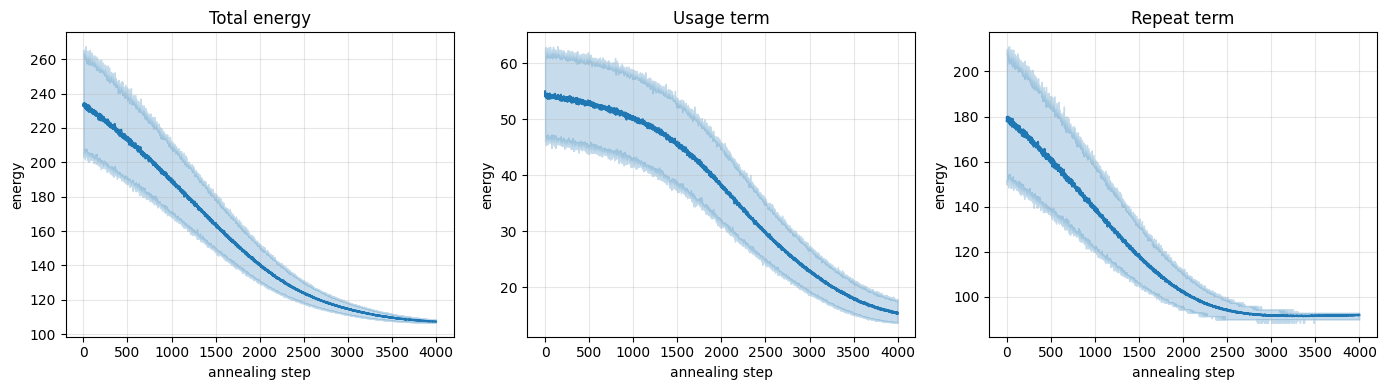

In [10]:
def plot_convergence(usage, repeat, color="C0", label=None):
    total = usage + repeat
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, data, name in zip(axes, [total, usage, repeat], ["Total energy", "Usage term", "Repeat term"]):
        x = np.arange(data.shape[1])
        ax.plot(x, data.mean(0), color=color, label=label)
        ax.fill_between(x, np.percentile(data, 5, 0), np.percentile(data, 95, 0), color=color, alpha=0.25)
        ax.set(title=name, xlabel="annealing step", ylabel="energy")
        ax.grid(alpha=0.3)
    if label:
        axes[0].legend()
    fig.tight_layout()


plot_convergence(potts_usage, potts_repeat)

Finally, we can decode the best chain's codon indices back into an actual nucleotide sequence — the optimized coding DNA we would hand to the lab.

In [ ]:
def indices_to_dna(seq, indices):
    return "".join(CODON_TABLE[aa][int(k)] for aa, k in zip(seq, indices))


best_dna = indices_to_dna(SEQ, potts_final[best_chain])
print(f"optimized coding DNA ({len(best_dna)} nucleotides), first 60:\n{best_dna[:60]}...")

## From categorical to binary: the Ising model

The Potts model above is the natural formulation, and it is what a future *categorical* probabilistic chip (with "p-dits") would run directly. But Extropic's near-term hardware is built from **binary** elements ("p-bits"), which sample Ising models — energy functions over spin variables $s_i \in \{-1, +1\}$. To run codon optimization on that hardware, we need to re-express our categorical Potts model using only binary spins.

The trick is **domain-wall encoding**. A categorical variable with $K$ states is represented by $K-1$ spins arranged in a "thermometer": state $k$ is encoded as the first $k$ spins being $+1$ and the rest $-1$. The single boundary between the $+1$ block and the $-1$ block — the *domain wall* — sits at position $k$ and thereby encodes the state. The lower part of panel **(b)** in the roadmap figure draws exactly this for a $K{=}6$ codon variable, alongside an *invalid* (non-thermometer) configuration.

Because a position with $K$ codons uses $K-1$ spins, the spin budget varies along the protein: a single-codon amino acid such as Methionine or Tryptophan ($K{=}1$) needs *zero* spins, since there is nothing to choose. Summed over our 100 positions this comes to 266 spins — well below the $100\times5$ we would need if every amino acid had the maximum of 6 codons.

Let's make the encoding concrete for a 4-state variable (3 spins):

In [12]:
K = 4
for state in range(K):
    spins = ["+1" if j < state else "-1" for j in range(K - 1)]
    print(f"state {state}:  [{', '.join(spins)}]")

state 0:  [-1, -1, -1]
state 1:  [+1, -1, -1]
state 2:  [+1, +1, -1]
state 3:  [+1, +1, +1]


Only these "thermometer" patterns are valid; a configuration like `[-1, +1, -1]` (a $+1$ to the right of a $-1$) does not correspond to any state. To forbid such *defects*, we add a ferromagnetic coupling of strength $P$ between neighboring spins within each position's chain — it costs energy to have a $-1$ immediately followed by a $+1$. Making $P$ large enforces validity.

Why this encoding rather than the more common one-hot encoding? In short, domain-wall encoding keeps the constraint graph a sparse *chain* (rather than a dense clique) and mixes well even when $P$ is large; see the paper for the full comparison.

We still need to translate the Potts *weights* into Ising weights. Here is the intuition for the *shape* of that translation: flipping a single thermometer spin moves the domain wall by one state, so what a spin actually "feels" is the *change* in Potts energy between adjacent states. That is why a unary Potts bias turns into a spin bias via a **first difference** of the bias across adjacent states, and a pairwise Potts coupling turns into a spin–spin coupling via a **second difference** (a difference of differences).

The exact formulas are mechanical (derived in the paper), and **you can treat `compile_dwc` below as a black box — feel free to skip its body.** What matters is the dictionary it returns, which holds everything needed to build the Ising model: per-spin biases, the within-position constraint edges, the between-position coupling edges, a 4-coloring for block updates, and index arrays to convert between the spin and codon representations.

In [13]:
def potts_to_spin(indices, pos_of_spin, spin_pos_index):
    """Codon indices [..., L] -> thermometer spins [..., n_spins] (bool, True means +1)."""
    return spin_pos_index < indices[..., pos_of_spin]


def spin_to_potts(spins, pos_matrix):
    """Thermometer spins -> codon indices [..., L] (the count of +1 spins at each position)."""
    return (spins.astype(jnp.int32) @ pos_matrix).astype(jnp.uint8)


def compile_dwc(biases, pairwise, Ks):
    """Compile the Potts weights into the static structure of the domain-wall Ising model."""
    biases, pairwise = np.asarray(biases), np.asarray(pairwise)
    L = len(Ks)

    # Lay out the spins: position p contributes Ks[p]-1 spins. Record, for each spin,
    # which position it belongs to (pos_of_spin) and its index within that position (spin_pos_index).
    pos_of_spin, spin_pos_index = [], []
    for p, K in enumerate(Ks):
        for j in range(K - 1):
            pos_of_spin.append(p)
            spin_pos_index.append(j)
    pos_of_spin = np.array(pos_of_spin)
    spin_pos_index = np.array(spin_pos_index)
    n_spins = len(pos_of_spin)
    offset = [sum(Ks[pp] - 1 for pp in range(p)) for p in range(L)]  # first spin index of position p

    # Per-spin Ising bias, split into a P-independent part (bias_base) and the boundary
    # term that scales with P (first_minus_last is +1 at a chain's start, -1 at its end).
    bias_base = np.zeros(n_spins, dtype=np.float32)
    first_minus_last = np.zeros(n_spins, dtype=np.float32)
    for s in range(n_spins):
        p, j, K = pos_of_spin[s], spin_pos_index[s], Ks[pos_of_spin[s]]
        b = (biases[p, j + 1] - biases[p, j]) / 2  # first difference of the unary bias
        if j == 0:
            first_minus_last[s] += 1.0
        if j == K - 2:
            first_minus_last[s] -= 1.0
        if p > 0:  # contribution from the coupling to the previous position
            W, Kl = pairwise[p - 1], Ks[p - 1]
            b += (W[0, j + 1] - W[0, j] + W[Kl - 1, j + 1] - W[Kl - 1, j]) / 4
        if p < L - 1:  # contribution from the coupling to the next position
            W, Kr = pairwise[p], Ks[p + 1]
            b += (W[j + 1, 0] - W[j, 0] + W[j + 1, Kr - 1] - W[j, Kr - 1]) / 4
        bias_base[s] = b

    # Constraint edges: the ferromagnetic chain inside each position (weight P/4).
    constraint_edges = [(offset[p] + j, offset[p] + j + 1) for p in range(L) for j in range(Ks[p] - 2)]

    # Coupling edges between adjacent positions, with weights from a second difference.
    inter_edges, inter_weights = [], []
    for p in range(L - 1):
        W = pairwise[p]
        for i in range(Ks[p] - 1):
            for j in range(Ks[p + 1] - 1):
                inter_edges.append((offset[p] + i, offset[p + 1] + j))
                inter_weights.append((W[i + 1, j + 1] - W[i, j + 1] - W[i + 1, j] + W[i, j]) / 4)

    spin_nodes = [SpinNode() for _ in range(n_spins)]

    # 4-coloring by (position parity, spin-index parity): no two same-color spins share an edge.
    colors = {}
    for s in range(n_spins):
        colors.setdefault((pos_of_spin[s] % 2, spin_pos_index[s] % 2), []).append(s)
    free_blocks = [Block([spin_nodes[s] for s in group]) for group in colors.values()]
    block_indices = [np.array(group, dtype=np.int32) for group in colors.values()]

    return {
        "spin_nodes": spin_nodes,
        "n_constraint": len(constraint_edges),
        "bias_base": jnp.array(bias_base),
        "first_minus_last": jnp.array(first_minus_last),
        "constraint_left": [spin_nodes[a] for a, b in constraint_edges],
        "constraint_right": [spin_nodes[b] for a, b in constraint_edges],
        "inter_left": [spin_nodes[a] for a, b in inter_edges],
        "inter_right": [spin_nodes[b] for a, b in inter_edges],
        "inter_weights": jnp.array(inter_weights, dtype=np.float32),
        "free_blocks": free_blocks,
        "block_indices": block_indices,
        "pos_of_spin": jnp.array(pos_of_spin),
        "spin_pos_index": jnp.array(spin_pos_index),
        "pos_matrix": jnp.array(np.eye(L, dtype=np.int32)[pos_of_spin]),
    }


dwc = compile_dwc(biases, pairwise, Ks)
n_spins = len(dwc["spin_nodes"])
print(
    f"{L} categorical codon variables  ->  {n_spins} binary spins "
    f"({dwc['n_constraint']} constraint edges, {len(dwc['inter_left'])} coupling edges)"
)

100 categorical codon variables  ->  266 binary spins (168 constraint edges, 707 coupling edges)


### Building and annealing the Ising model

Building the Ising program mirrors the Potts one, but with `SpinEBMFactor` and `SpinGibbsConditional` (example 02) and three factor groups: the per-spin biases, the within-position constraint couplings (weight $P/4$), and the between-position couplings. This is the graph in panel **(c)** of the roadmap figure — within-position *constraint* edges and between-position *interaction* edges, 4-colored for parallel updates. As before, lowering the temperature scales every weight by $\beta$.

We anneal **two** parameters at once. Alongside the inverse temperature $\beta$, we ramp the constraint strength $P$ on its own schedule: we keep $P$ small at first so the sampler is allowed to pass *through* invalid configurations as shortcuts between valid ones, then raise it so that the final states settle into valid thermometers (which we verify below). (The $\beta$ range differs from the Potts model because the domain-wall compilation rescales the weights; these schedules were chosen empirically and you can tune them.)

In [ ]:
ISING_STEPS = 500
ISING_SWEEPS_PER_STEP = 10
ISING_BETA_MIN, ISING_BETA_MAX = 2.0, 200.0
ISING_P_MIN, ISING_P_MAX = 2.0, 200.0
ISING_N_CONST_P = 25  # keep P at its minimum for this many initial steps before ramping it up


def build_ising_program(beta, P):
    """An Ising FactorSamplingProgram for the given temperature (beta) and constraint strength (P)."""
    ising_biases = (dwc["bias_base"] + dwc["first_minus_last"] * (P / 4)) * beta
    factors = [SpinEBMFactor([Block(dwc["spin_nodes"])], ising_biases)]
    if dwc["n_constraint"] > 0:
        constraint_weights = jnp.full(dwc["n_constraint"], P * beta / 4)
        factors.append(
            SpinEBMFactor([Block(dwc["constraint_left"]), Block(dwc["constraint_right"])], constraint_weights)
        )
    if dwc["inter_left"]:
        factors.append(
            SpinEBMFactor([Block(dwc["inter_left"]), Block(dwc["inter_right"])], dwc["inter_weights"] * beta)
        )
    spec = BlockGibbsSpec(dwc["free_blocks"], [])
    samplers = [SpinGibbsConditional() for _ in spec.free_blocks]
    return FactorSamplingProgram(spec, samplers, factors, [])


@eqx.filter_jit
def anneal_ising(key):
    betas = jnp.logspace(jnp.log10(ISING_BETA_MIN), jnp.log10(ISING_BETA_MAX), ISING_STEPS)
    Ps = jnp.concatenate(
        [
            jnp.full(ISING_N_CONST_P, ISING_P_MIN),
            jnp.logspace(jnp.log10(ISING_P_MIN), jnp.log10(ISING_P_MAX), ISING_STEPS - ISING_N_CONST_P),
        ]
    )
    schedule = SamplingSchedule(n_warmup=ISING_SWEEPS_PER_STEP, n_samples=1, steps_per_sample=1)
    all_block = Block(dwc["spin_nodes"])

    def step(spins, step_input):
        step_key, beta, P = step_input
        program = build_ising_program(beta, P)
        blocks = [spins[:, idx] for idx in dwc["block_indices"]]  # split into the 4 color groups
        chain_keys = jax.random.split(step_key, N_CHAINS)
        # As in the Potts anneal, [0][0] pulls the single observed block's single sample
        # out of sample_states' output — here the new spin vector.
        new_spins = jax.vmap(lambda k, b: sample_states(k, program, schedule, b, [], [all_block])[0][0])(
            chain_keys, blocks
        )
        energies = jax.vmap(lambda s: codon_energy(spin_to_potts(s, dwc["pos_matrix"])))(new_spins)
        return new_spins, energies

    # Start from random valid codons, converted to thermometer spins.
    init_key, scan_key = jax.random.split(key)
    pos_keys = jax.random.split(init_key, L)
    init_codons = jax.vmap(lambda k, n: jax.random.randint(k, (N_CHAINS,), 0, n, dtype=jnp.uint8))(
        pos_keys, jnp.array(Ks)
    ).T
    init_spins = potts_to_spin(init_codons, dwc["pos_of_spin"], dwc["spin_pos_index"])

    final_spins, (usage, repeat) = jax.lax.scan(step, init_spins, (jax.random.split(scan_key, ISING_STEPS), betas, Ps))
    final_codons = spin_to_potts(final_spins, dwc["pos_matrix"])
    return final_codons, final_spins, usage.T, repeat.T

In [15]:
ising_codons, ising_spins, ising_usage, ising_repeat = anneal_ising(jax.random.key(SEED))
ising_codons, ising_spins = np.array(ising_codons), np.array(ising_spins)
ising_total = np.array(ising_usage + ising_repeat)

best_ising = int(np.argmin(ising_total[:, -1]))
print(
    f"final energy: {ising_total[:, -1].mean():.2f} +/- {ising_total[:, -1].std():.2f} "
    f"(mean over {N_CHAINS} chains)"
)
print(f"best energy found: {ising_total[best_ising, -1]:.2f}")

# Check that every final state is a valid thermometer (no leftover defects).
expected = np.array(dwc["spin_pos_index"]) < ising_codons[:, np.array(dwc["pos_of_spin"])]
valid_fraction = (expected == ising_spins).all(axis=1).mean()
print(f"defect-free final states: {100 * valid_fraction:.1f}%")

final energy: 107.41 +/- 0.68 (mean over 512 chains)
best energy found: 106.37
defect-free final states: 100.0%


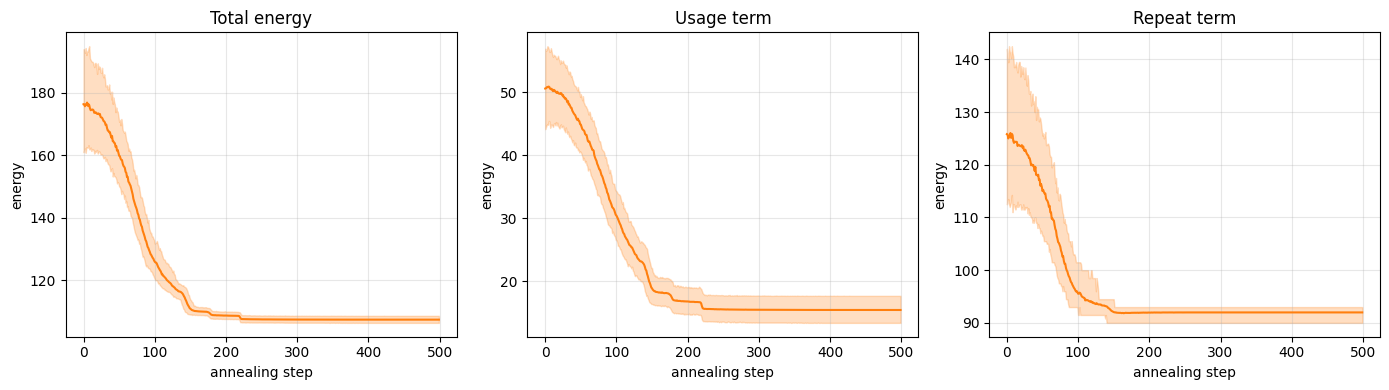

In [16]:
plot_convergence(ising_usage, ising_repeat, color="C1")

## Comparing the two models

The two formulations describe the *same* optimization problem in different variables, so they should reach the same answer — and they do. The histogram below shows the final energy reached by all 512 chains for each model: the two distributions overlap closely, and both achieve the same best energy. This confirms that the domain-wall encoding faithfully reproduces the Potts objective.

Potts best: 106.37    Ising best: 106.37


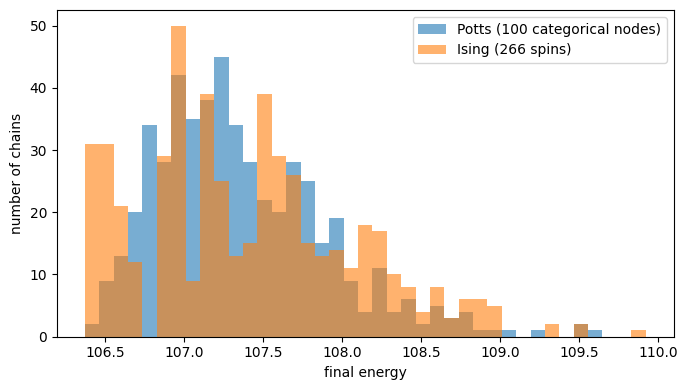

In [17]:
plt.figure(figsize=(7, 4))
bins = np.linspace(
    min(potts_total[:, -1].min(), ising_total[:, -1].min()), max(potts_total[:, -1].max(), ising_total[:, -1].max()), 40
)
plt.hist(potts_total[:, -1], bins=bins, alpha=0.6, label=f"Potts ({L} categorical nodes)")
plt.hist(ising_total[:, -1], bins=bins, alpha=0.6, label=f"Ising ({n_spins} spins)")
plt.xlabel("final energy")
plt.ylabel("number of chains")
plt.legend()
plt.tight_layout()

print(f"Potts best: {potts_total[:, -1].min():.2f}    Ising best: {ising_total[:, -1].min():.2f}")

## Wrap-up

We framed a real combinatorial design problem — choosing codons for a protein — as energy minimization, and solved it two ways with THRML:

- A **Potts model** that works directly with the categorical codon variables, optimized by simulated annealing. This is the compact, natural formulation, using just 100 categorical variables — one per amino acid.
- An **Ising model**, obtained from the Potts model via domain-wall encoding, that uses only binary spins and so can run on near-term Extropic hardware. It needs more variables (266 spins) to express the same problem, but reaches the same optimum.

(The annealing schedules here are deliberately generous so they keep working as you vary the settings; for this simplified two-term objective the energy has largely plateaued by the end of the schedule — as the convergence plots show — so you can shorten the schedules to trade a little quality for speed.)

The paper this example is based on takes the next step: it estimates the *energy cost* of running this optimization, and finds that a thermodynamic chip could solve it for orders of magnitude less energy than a GPU. See [github.com/extropic-ai/codon_opt](https://github.com/extropic-ai/codon_opt) for the complete code, including the GC-content term we omitted here.

More broadly, the pattern shown here — **design an energy function whose minimum is the solution you want, then let a probabilistic computer find it** — applies far beyond codon optimization. Many problems in drug discovery and scientific computing reduce to exactly this kind of energy minimization, and they are precisely what thermodynamic hardware is built to accelerate.